In [65]:
from langchain_ollama import OllamaLLM, OllamaEmbeddings, ChatOllama
from langgraph.graph import StateGraph , START , END
from langchain_core.prompts import PromptTemplate
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyPDFLoader
from pydantic import BaseModel
from langchain_core.documents import Document
import re
from typing import List

In [46]:
docs = (
    PyPDFLoader("./sample_document_1.pdf").load() +
    PyPDFLoader("./sample_document_2.pdf").load() +
    PyPDFLoader("./sample_document_3.pdf").load()
)

In [47]:
docs

[Document(metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-02-28T11:31:20+05:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-28T11:31:20+05:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': './sample_document_1.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content="The Evolution of Artificial Intelligence and Machine\n Learning\nArtificial intelligence has undergone remarkable transformations since its inception in the mid-20th\ncentury. The field began with ambitious goals of creating machines that could think and reason like\nhumans, leading to early successes in symbolic reasoning and expert systems. However, these early\napproaches faced significant limitations, particularly in handling uncertainty and learning from\nexperience. The 1980s and 1990s saw the rise of machine learning techniques, which shifted the focus\nfrom hand-coded rules to data-driv

In [48]:
embedding_model = OllamaEmbeddings(model="all-minilm:33m")
llm = OllamaLLM(model = "gemma3:4b")
chat_llm = ChatOllama(model = "gemma3:4b", temperature=0.7)

In [49]:
chunks = RecursiveCharacterTextSplitter(chunk_size= 500, chunk_overlap = 100).split_documents(docs)

In [50]:
chunks[0].page_content

'The Evolution of Artificial Intelligence and Machine\n Learning\nArtificial intelligence has undergone remarkable transformations since its inception in the mid-20th\ncentury. The field began with ambitious goals of creating machines that could think and reason like\nhumans, leading to early successes in symbolic reasoning and expert systems. However, these early\napproaches faced significant limitations, particularly in handling uncertainty and learning from'

In [51]:
# Create vector store and save to disk for persistence
vector_store = FAISS.from_documents(chunks, embedding_model)
vector_store.save_local("faiss_index")

In [52]:
# To load the vector store from disk later (skip the above cells):
# vector_store = FAISS.load_local("faiss_index", embedding_model, allow_dangerous_deserialization=True)

In [66]:
retriever = vector_store.as_retriever(search_type = "similarity", search_kwargs = {"k": 4})

In [54]:
class State(BaseModel):
    question: str
    docs: list[Document]
    answer: str

    strips: list[str]
    kept_strips: list[str]
    refined_content: str

    answer : str



In [67]:
def retriver(state: State):
    q = state.question
    return {"docs": retriever.invoke(q)}

In [68]:
def generator(state: State):
    q = state.question
    context = state.refined_content if state.refined_content else "\n\n".join([doc.page_content for doc in state.docs])
    prompt = PromptTemplate.from_template(
        "Use the context below to answer the question concisely.\n\nContext:\n{context}\n\nQuestion: {question}\nAnswer:"
    )
    answer = (prompt | llm).invoke({"context": context, "question": q})
    return {"answer": answer}

In [57]:
def decompose_to_sentence(text: str)-> list[str]:
    text = re.sub(r'\s+', ' ', text.strip())
    sentence = re.split(r'(?<=[.!?]) +', text)
    return [s.strip() for s in sentence if s.strip()]


In [58]:
class KeepOrDrop(BaseModel):
    keep: bool

prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a strict relevance filter.\n"
        "Return true only if the sentence directly helps answer the question.\n"
        "Use ONLY the sentence. Output JSON only"
    ),
    ("human", "Question:{question}\nSentence: {sentence}")
])

filter_chain = prompt | chat_llm.with_structured_output(KeepOrDrop)

In [69]:
def refine(state: State)-> State:
    q = state.question

    content = "\n\n".join([doc.page_content for doc in state.docs])

    strips = decompose_to_sentence(content)

    kept: List[str] = []

    for s in strips:
        if filter_chain.invoke({"question": q, "sentence" : s}).keep:
            kept.append(s)

    refined_content = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_content": refined_content,
    }


In [70]:
graph = StateGraph(State)
graph.add_node("retriver", retriver)
graph.add_node("refiner", refine)
graph.add_node("generator", generator)

graph.add_edge(START, "retriver")
graph.add_edge("retriver", "refiner")
graph.add_edge("refiner", "generator")
graph.add_edge("generator", END)



In [71]:
app = graph.compile()

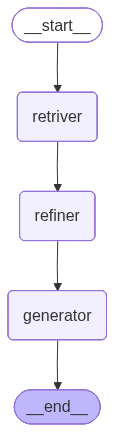

In [62]:
app

In [72]:
res  = app.invoke({
                   "question": "What are the main topics covered in the documents?",
                   "docs": [],
                   "answer": "",
                   "strips": [],
                   "kept_strips": [],
                   "refined_content": "",})

In [74]:
res["answer"]

'Space exploration (Mars) and climate change (Paris Climate Accord).'